# Lab 4: Linear Regression & Its Variants

> Predicting Continuous Values with Scikit-Learn and Real-World Data

**Course:** CS4082 – Machine Learning  
**Instructor:** Dr. Naila Marir  
**Student Name:** Sarah Alsebae  
**Student ID:** S23108327  
**Semester:** Spring 2026

#Part 1: The Idea Behind Linear Regression

* Linear regression is a method used to find the best straight line that connects input values (features) to a continuous output value. For one input feature, the model predicts the output using a simple equation: predicted value equals the slope times the input plus an intercept. For multiple input features, the model adds together each feature multiplied by its own weight, plus the intercept.

* The goal during training is to choose the weights that make the predictions as close as possible to the actual values. In scikit-learn’s LinearRegression, this is done by minimizing something called Ordinary Least Squares (OLS). This means the model tries to make the sum of the squared differences between the real values and the predicted values as small as possible.

* The errors are squared for two main reasons: to make sure negative and positive errors do not cancel each other out, and to make larger mistakes count more heavily than smaller ones. This helps the model avoid big prediction errors and find the best-fitting line.


#Part 2: Loading a Real Dataset – California Housing

##2.1  Load and Explore


In [175]:
import numpy as np
import pandas as pd
import matplotlib . pyplot as plt
from sklearn . datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing ()
df = pd . DataFrame ( housing . data , columns = housing . feature_names )
df ['MedHouseVal'] = housing . target # target in $100 ,000 s

print ( f'Dataset shape : {df. shape }')
print ( f'\nFeature names :\n{ housing . feature_names }')
print ( f'\nFirst 5 rows :')
print ( df . head () )
print ( f'\nBasic statistics :')
print ( df . describe () . round (3) )

Dataset shape : (20640, 9)

Feature names :
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows :
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic statistics :
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      

##2.2  Visualize Relationships


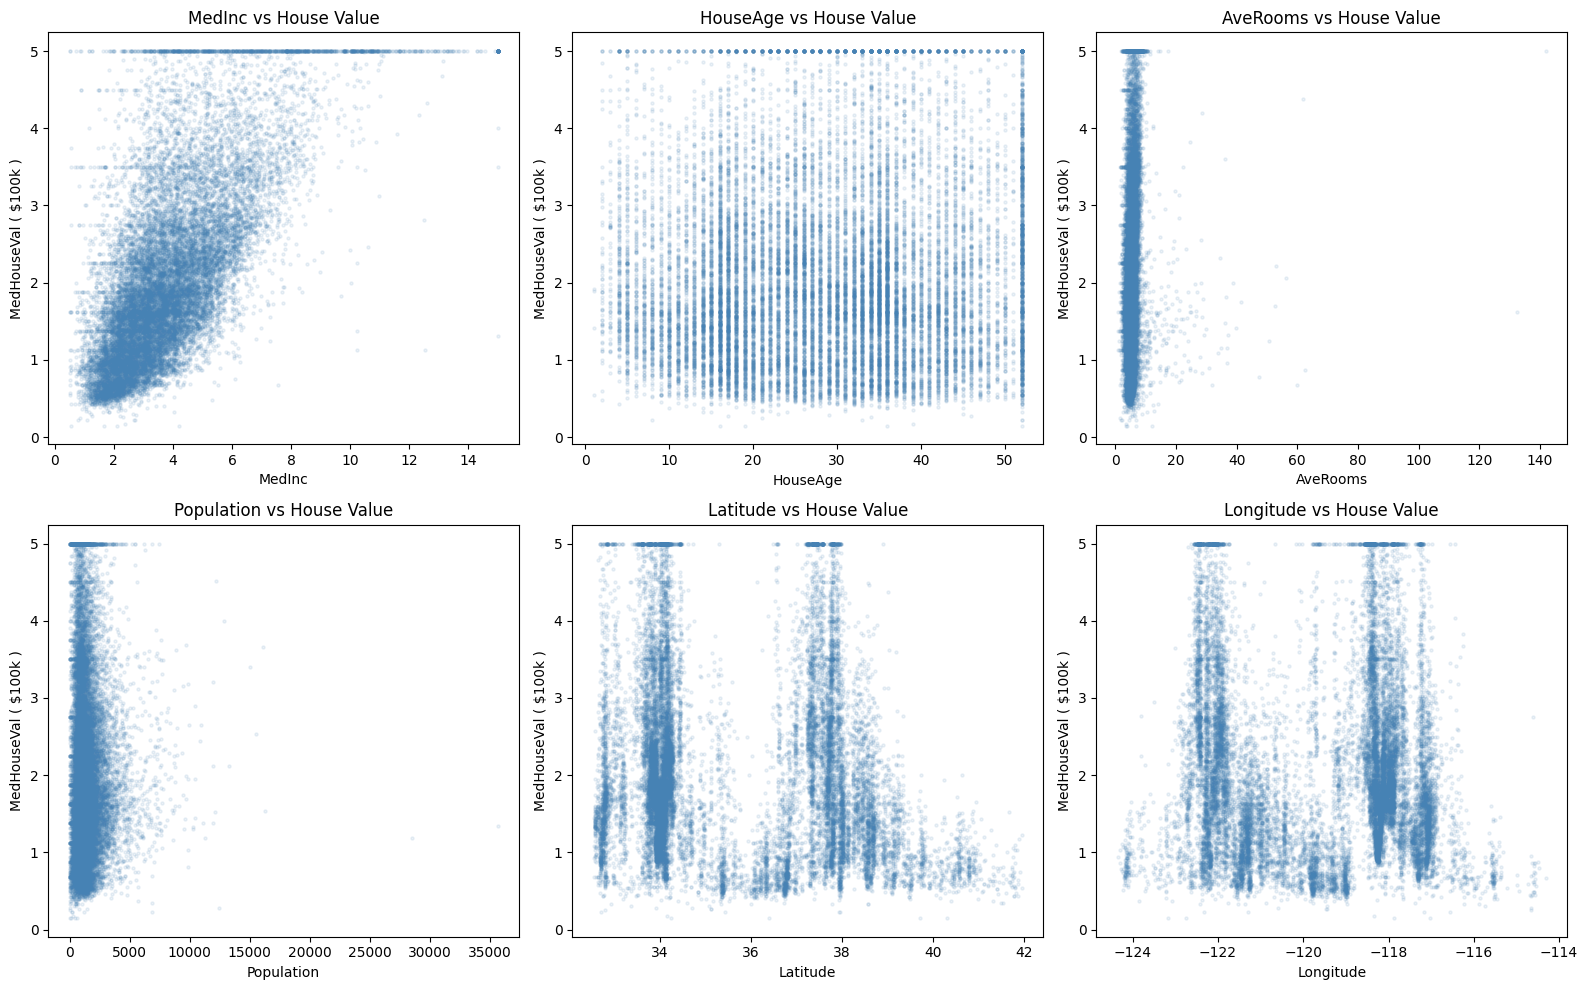

In [176]:
fig , axes = plt . subplots (2 , 3 , figsize =(16 , 10) )
features_to_plot = ['MedInc', 'HouseAge', 'AveRooms',
'Population', 'Latitude', 'Longitude']

for ax , feat in zip( axes . flatten () , features_to_plot ) :
    ax . scatter ( df [ feat ] , df ['MedHouseVal'] ,
    alpha =0.1 , s =5 , color ='steelblue' )
    ax . set_xlabel ( feat )
    ax . set_ylabel ('MedHouseVal ( $100k )')
    ax . set_title ( f'{ feat } vs House Value' )

plt . tight_layout ()
plt . show ()

#Task 1: Explore the Dataset

Correlation with MedHouseVal:
 MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


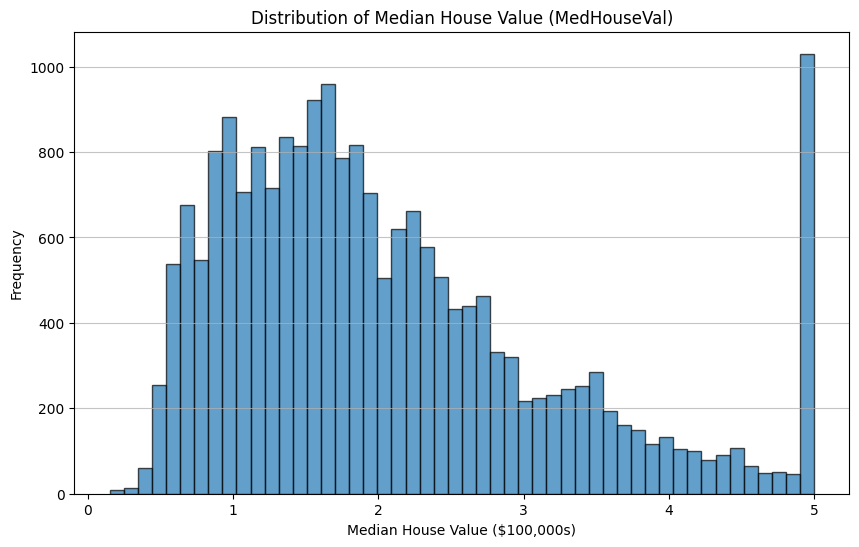

In [177]:
#Use df.corr()[’MedHouseVal’].sort values() to rank features by their correlation with the target. Which feature has the strongest correlation?
correlation = df.corr()['MedHouseVal'].sort_values(ascending=False)
print("Correlation with MedHouseVal:\n", correlation)

#Plot the distribution of MedHouseVal using plt.hist(df[’MedHouseVal’], bins=50). Is the target normally distributed? Do you notice any cap at $5.0 (i.e., $500,000)?
plt.figure(figsize=(10, 6))
plt.hist(df['MedHouseVal'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Median House Value (MedHouseVal)')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

**1. Use df.corr()[’MedHouseVal’].sort values() to rank features by their correlation with the target. Which feature has the strongest correlation?**

> 'MedInc' (Median Income) has the strongest positive correlation with median house value.

**2. Plot the distribution of MedHouseVal using plt.hist(df[’MedHouseVal’], bins=50). Is the target normally distributed? Do you notice any cap at $5.0 (i.e., $500,000)?**

>  No, the target is not normally distributed; it's right-skewed. Yes, there is a clear cap at $5.0 (i.e., $500,000).

**3. How many samples are in the dataset? Is this enough for training a good model?**

> There are 20,640 samples in the dataset. This is generally enough for training a good model.

#Part 3: Simple Linear Regression (One Feature)

##3.1 Prepare Data

In [178]:
from sklearn . model_selection import train_test_split

# Use only MedInc as the feature
X_simple = df [['MedInc']].values
y = df ['MedHouseVal'].values

# Split : 80% train , 20% test
X_train , X_test , y_train , y_test = train_test_split (
X_simple , y , test_size =0.2 , random_state =42)

print ( f'Training samples : {X_train.shape[0]}')
print ( f'Testing samples : {X_test.shape[0]}')

Training samples : 16512
Testing samples : 4128


##3.2 Train and Visualize

Slope (w1): 0.4193
Intercept (w0): 0.4446

Equation : y = 0.4193 * MedInc ’f’+ (0.4446)


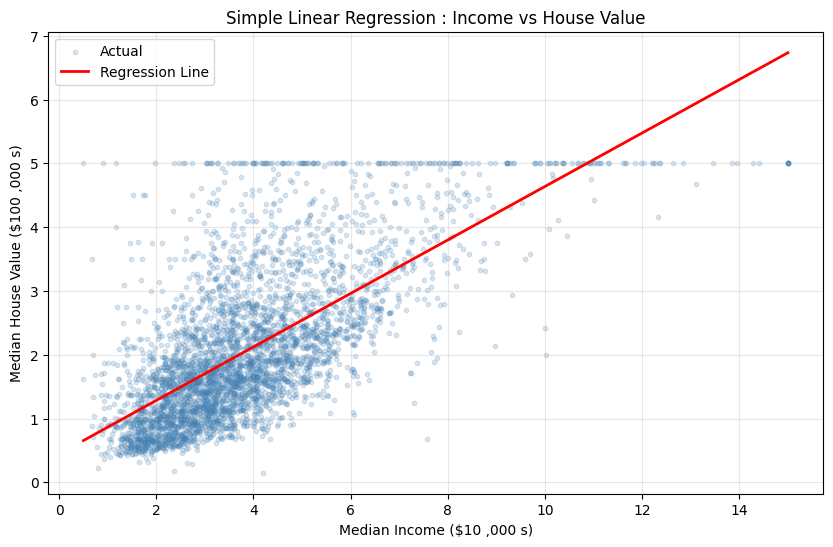

In [179]:
from sklearn . linear_model import LinearRegression

# Train
model_simple = LinearRegression ()
model_simple . fit ( X_train , y_train )

# Print the learned parameters
print ( f'Slope (w1): { model_simple . coef_ [0]:.4f}')
print ( f'Intercept (w0): { model_simple . intercept_ :.4f}')
print ( f'\nEquation : y = { model_simple . coef_ [0]:.4f} * MedInc ’f’+ ({ model_simple . intercept_ :.4f})')


# Visualize : scatter + regression line
plt . figure ( figsize =(10 , 6) )
plt . scatter ( X_test , y_test , alpha =0.2 , s =10 ,
color ='steelblue' , label ='Actual' )

# Draw the regression line
x_line = np . linspace ( X_test .min () , X_test .max () , 100)
y_line = model_simple . predict ( x_line . reshape ( -1 , 1) )
plt . plot ( x_line , y_line , color ='red' , linewidth =2 ,
label ='Regression Line' )

plt . xlabel ('Median Income ($10 ,000 s)')
plt . ylabel ('Median House Value ($100 ,000 s)')
plt . title ('Simple Linear Regression : Income vs House Value')
plt . legend ()
plt . grid (True , alpha =0.3)
plt . show ()

#Task 2: Interpret the Simple Model

Slope (w1): 0.4193
Intercept (w0): 0.4446
Equation: y = 0.4193 * MedInc + 0.4446

Predicted house value for MedInc = 5.0 (by hand): $254,128.98
Predicted house value for MedInc = 5.0 (by model): $254128.98
Training samples: 16512
Testing samples: 4128
Slope (w1): 0.0095
Intercept (w0): 1.7998
Equation: y = 0.0095 * HouseAge + 1.7998



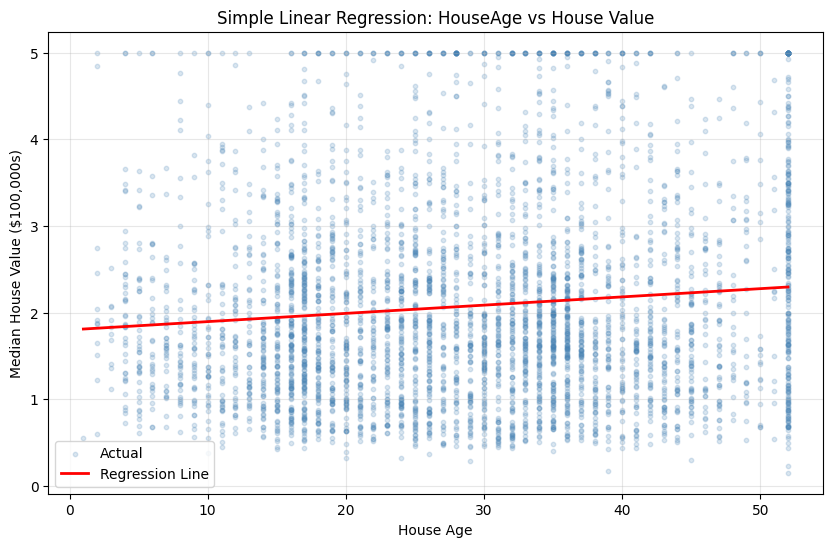


The model using MedInc is better. The scatter plot shows a clear upward trend, and the regression line fits the data well.
The model using HouseAge is worse because the data points are widely scattered and the regression line is almost flat.
This shows that median income has a stronger relationship with house prices than house age.


In [180]:
#What are the slope and intercept your model learned? Write the equation.
slope = model_simple.coef_[0]
intercept = model_simple.intercept_
print(f"Slope (w1): {slope:.4f}")
print(f"Intercept (w0): {intercept:.4f}")
print(f"Equation: y = {slope:.4f} * MedInc + {intercept:.4f}")

#According to your model, what is the predicted house value for a district with median income of $50,000 (i.e., MedInc = 5.0)? Calculate by hand and verify with model simple.predict([[5.0]]).
med_inc_5 = 5.0
predicted_by_hand = slope * med_inc_5 + intercept
predicted_by_model = model_simple.predict([[med_inc_5]])[0]
print(f"\nPredicted house value for MedInc = 5.0 (by hand): ${predicted_by_hand * 100000:,.2f}")
print(f"Predicted house value for MedInc = 5.0 (by model): ${predicted_by_model * 100000:.2f}")

#Try training a simple model using HouseAge instead of MedInc. Is it better or worse? Why?
from sklearn.model_selection import train_test_split

# Use only HouseAge as the feature
X_age = df[['HouseAge']].values
y = df['MedHouseVal'].values

# Split: 80% train, 20% test
X_train_age, X_test_age, y_train_age, y_test_age = train_test_split(
    X_age, y, test_size=0.2, random_state=42)

print(f'Training samples: {X_train_age.shape[0]}')
print(f'Testing samples: {X_test_age.shape[0]}')

from sklearn.linear_model import LinearRegression

# Train
model_houseage = LinearRegression()
model_houseage.fit(X_train_age, y_train_age)

# Print learned parameters
print(f'Slope (w1): {model_houseage.coef_[0]:.4f}')
print(f'Intercept (w0): {model_houseage.intercept_:.4f}')
print(f'Equation: y = {model_houseage.coef_[0]:.4f} * HouseAge + {model_houseage.intercept_:.4f}\n')


# Visualize : scatter + regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test_age, y_test_age, alpha=0.2, s=10,
            color='steelblue', label='Actual')

x_line = np.linspace(X_test_age.min(), X_test_age.max(), 100)
y_line = model_houseage.predict(x_line.reshape(-1, 1))

plt.plot(x_line, y_line, color='red', linewidth=2,
         label='Regression Line')

plt.xlabel('House Age')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Simple Linear Regression: HouseAge vs House Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nThe model using MedInc is better. The scatter plot shows a clear upward trend, and the regression line fits the data well.\nThe model using HouseAge is worse because the data points are widely scattered and the regression line is almost flat.\nThis shows that median income has a stronger relationship with house prices than house age.")

#Part 4: Evaluating Regression Models

##4.1 Evaluate the Simple Model


In [181]:
from sklearn . metrics import mean_squared_error , mean_absolute_error , r2_score

# Predictions
y_pred_simple = model_simple . predict ( X_test )

# Calculate metrics
mse = mean_squared_error ( y_test , y_pred_simple )
rmse = np . sqrt ( mse )
mae = mean_absolute_error ( y_test , y_pred_simple )
r2 = r2_score ( y_test , y_pred_simple )

print ('=== Simple Linear Regression ( MedInc only ) === ')
print ( f'MSE: {mse :.4f}')
print ( f'RMSE : { rmse :.4f} ( error in $100 ,000 s)')
print ( f'MAE: {mae :.4f} ( error in $100 ,000 s)')
print ( f'R^2: {r2 :.4f} ({ r2 *100:.1f}% variance explained )')

=== Simple Linear Regression ( MedInc only ) === 
MSE: 0.7091
RMSE : 0.8421 ( error in $100 ,000 s)
MAE: 0.6299 ( error in $100 ,000 s)
R^2: 0.4589 (45.9% variance explained )


##4.2 Visualize Predictions vs. Actual


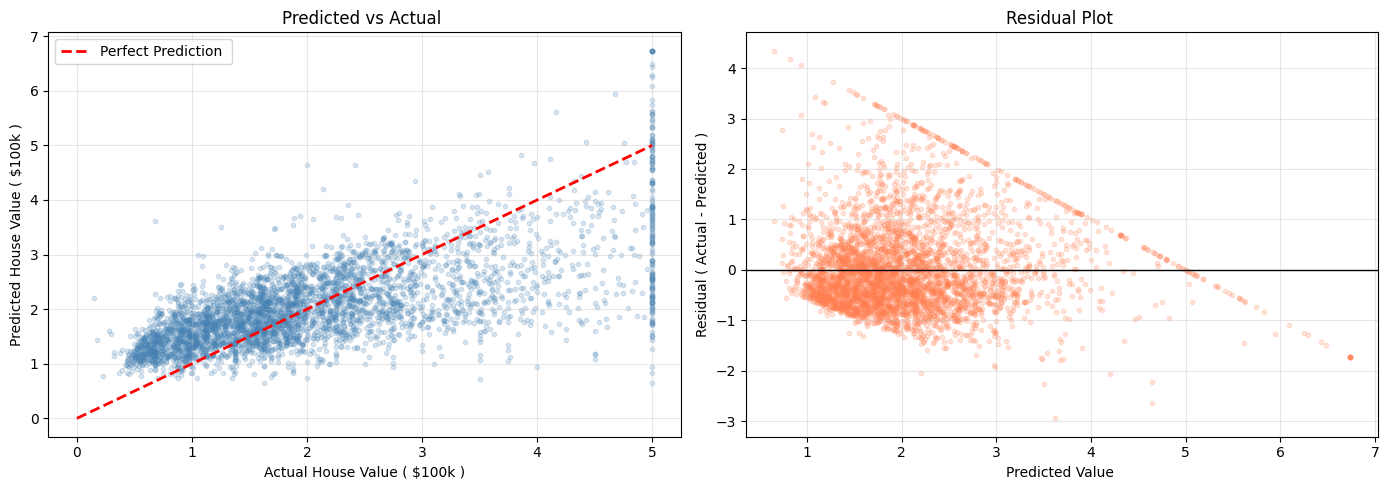

In [182]:
fig , axes = plt . subplots (1 , 2 , figsize =(14 , 5) )

# Plot 1: Predicted vs Actual
axes [0]. scatter ( y_test , y_pred_simple , alpha =0.2 , s =10 ,
color ='steelblue')
axes [0]. plot ([0 , 5] , [0 , 5] , 'r--', linewidth =2 ,
label ='Perfect Prediction ')
axes [0]. set_xlabel ('Actual House Value ( $100k )')
axes [0]. set_ylabel ('Predicted House Value ( $100k )')
axes [0]. set_title ('Predicted vs Actual ')
axes [0]. legend ()
axes [0]. grid (True , alpha =0.3)

# Plot 2: Residuals ( errors )
residuals = y_test - y_pred_simple
axes [1]. scatter ( y_pred_simple , residuals , alpha =0.2 , s =10 ,
color ='coral')
axes [1]. axhline ( y =0 , color ='black', linewidth =1)
axes [1]. set_xlabel ('Predicted Value ')
axes [1]. set_ylabel ('Residual ( Actual - Predicted )')
axes [1]. set_title ('Residual Plot ')
axes [1]. grid (True , alpha =0.3)

plt . tight_layout ()
plt . show ()

#Task 3: Understand the Metrics

**1. Convert the RMSE to actual dollars. If RMSE ≈ 0.74, what is the average prediction error in dollars?**

> The RMSE is approximately 0.8421 (in 100,000s), so the average prediction error in dollars is 84,210 (0.8421 * 100,000).

**2.Look at the “Predicted vs Actual” plot. Where does the model struggle most – at low values, high values, or both?**

> The model struggles most at higher house values, primarily due to the data being capped at $500,000. It also shows a spread of predictions across the range, indicating some struggle at various value levels.

**3. What does the R2 value tell you? Is a single feature enough to predict house prices well?**

> The R2 value (around 0.4589) tells us that approximately 45.9% of the variation in house prices can be explained by median income alone. A single feature (MedInc) is not enough to predict house prices well, as nearly half of the variation remains unexplained.


#Part 5: Multiple Linear Regression (All Features)

##5.1  Train with All Features

In [183]:
from sklearn . preprocessing import StandardScaler
from sklearn . pipeline import Pipeline

# Use all features
X_all = df . drop ( columns =['MedHouseVal'] ) . values
y = df ['MedHouseVal']. values

# Split
X_train , X_test , y_train , y_test = train_test_split (
X_all , y , test_size =0.2 , random_state =42)

# Build pipeline with scaling ( good practice !)
pipe_lr = Pipeline ([
('scaler' , StandardScaler () ) ,
('lr' , LinearRegression () )
])

pipe_lr . fit ( X_train , y_train )
y_pred_multi = pipe_lr . predict ( X_test )

# Evaluate
r2_multi = r2_score ( y_test , y_pred_multi )
rmse_multi = np . sqrt ( mean_squared_error ( y_test , y_pred_multi ) )

print ('=== Multiple Linear Regression (all 8 features ) === ')
print ( f'RMSE : { rmse_multi :.4f}')
print ( f'R^2: { r2_multi :.4f} ({ r2_multi *100:.1f}% variance explained )')
print ( f'\nImprovement over simple model :')
print ( f' R^2: {r2 :.4f} -> { r2_multi :.4f} '
f'(+{( r2_multi - r2) *100:.1f}%) ')

=== Multiple Linear Regression (all 8 features ) === 
RMSE : 0.7456
R^2: 0.5758 (57.6% variance explained )

Improvement over simple model :
 R^2: 0.4589 -> 0.5758 (+11.7%) 


##5.2 Feature Importance – Which Features Matter Most?

Feature Importance (by | coefficient |):
  Feature   Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


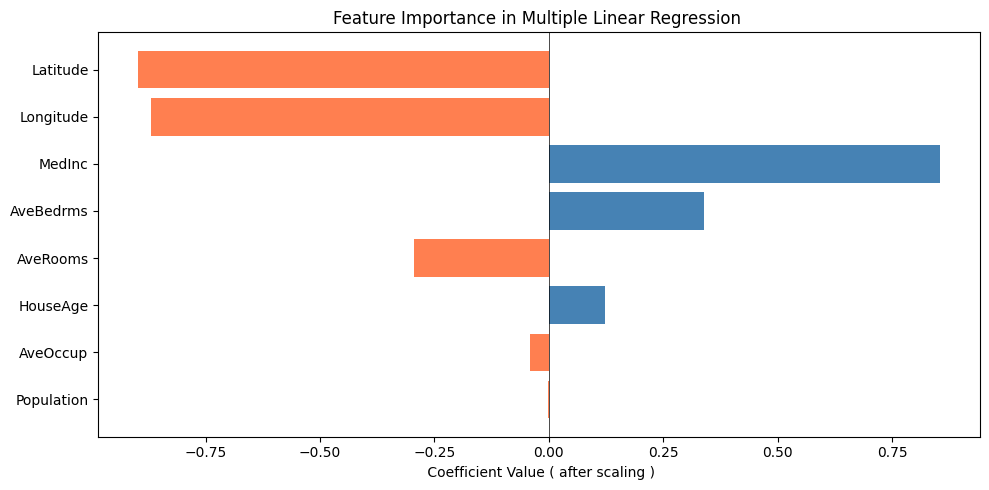

In [184]:
# Extract the learned coefficients
lr_model = pipe_lr . named_steps ['lr']
feature_names = housing . feature_names

# Since we scaled , coefficients are comparable
coef_df = pd . DataFrame ({
'Feature ': feature_names ,
'Coefficient': lr_model . coef_
}) . sort_values ('Coefficient', key =abs , ascending = False )

print ('Feature Importance (by | coefficient |):')
print ( coef_df . to_string ( index = False ) )

# Visualize
plt . figure ( figsize =(10 , 5) )
colors = ['steelblue' if c > 0 else 'coral'
for c in coef_df ['Coefficient']]
plt . barh ( coef_df ['Feature '] , coef_df ['Coefficient'] , color = colors )
plt . xlabel (' Coefficient Value ( after scaling )')
plt . title ('Feature Importance in Multiple Linear Regression ')
plt . axvline ( x =0 , color ='black', linewidth =0.5)
plt . gca () . invert_yaxis ()
plt . tight_layout ()
plt . show ()

#Task 4: Analyze Multiple Regression


**1. List the top 3 most important features and the bottom 3. Does this make intuitive sense?**

> The top 3 most important features are Latitude, Longitude, and Median Income (MedInc). The bottom 3 are Population, Average Occupancy (AveOccup), and House Age. This makes intuitive sense because location (Latitude, Longitude) and wealth (MedInc) are major drivers of house prices.

**2. Why does Latitude have a negative coefficient? What does this mean geographically for California?**

> A negative coefficient for Latitude means that as you move north in California (higher latitude), the median house value tends to decrease. Geographically, this indicates that the more expensive areas are generally in the southern and central coastal regions, and prices tend to be lower as you go further north.



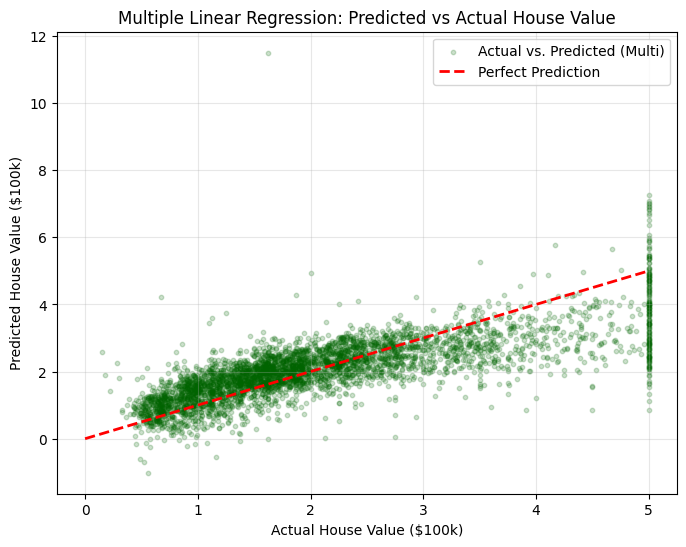


Visual Comparison:
Comparing this plot with the simple model's 'Predicted vs Actual' plot, the points for the multiple regression model appear to be more tightly clustered around the diagonal line. 
This indicates that the multiple regression model's predictions are generally more accurate and closer to the actual values than those of the simple linear regression model, 
which is expected as it uses more features.


In [185]:
#Create the “Predicted vs Actual” plot for the multiple regression model. Compare it visually with the simple model. Is it closer to the diagonal?

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_multi, alpha=0.2, s=10, color='darkgreen', label='Actual vs. Predicted (Multi)')
plt.plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual House Value ($100k)')
plt.ylabel('Predicted House Value ($100k)')
plt.title('Multiple Linear Regression: Predicted vs Actual House Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nVisual Comparison:")
print("Comparing this plot with the simple model's 'Predicted vs Actual' plot, the points for the multiple regression model appear to be more tightly clustered around the diagonal line. \nThis indicates that the multiple regression model's predictions are generally more accurate and closer to the actual values than those of the simple linear regression model, \nwhich is expected as it uses more features.")

#Part 6: Polynomial Regression

##6.1  Polynomial on a Single Feature

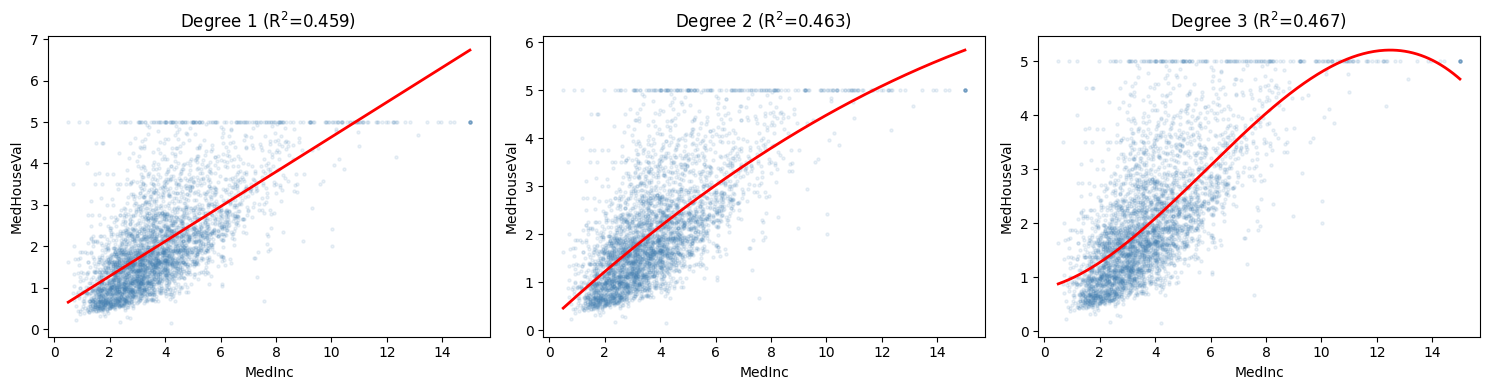


Polynomial Degree Comparison ( MedInc only ):
 Degree 1: R ^2=0.4589 ,  RMSE =0.8421
 Degree 2: R ^2=0.4633 ,  RMSE =0.8386
 Degree 3: R ^2=0.4671 ,  RMSE =0.8356


In [186]:
from sklearn . preprocessing import PolynomialFeatures

# Use only MedInc
X_simple = df [['MedInc']].values
X_train_s , X_test_s , y_train , y_test = train_test_split (
X_simple , y , test_size =0.2 , random_state =42)

# Try degrees 1 , 2 , and 3
results = {}
plt . figure ( figsize =(15 , 4) )

for i , degree in enumerate ([1 , 2 , 3]) :
    pipe_poly = Pipeline ([
    ('poly', PolynomialFeatures ( degree = degree ,
    include_bias = False ) ) ,
    ('lr', LinearRegression () )
    ])
    pipe_poly . fit ( X_train_s , y_train )
    y_pred = pipe_poly . predict ( X_test_s )

    r2_val = r2_score ( y_test , y_pred )
    rmse_val = np . sqrt ( mean_squared_error ( y_test , y_pred ) )
    results [ degree ] = {'R2': r2_val , 'RMSE': rmse_val }

    # Plot
    ax = plt . subplot (1 , 3 , i + 1)
    ax . scatter ( X_test_s , y_test , alpha =0.1 , s =5 ,
    color ='steelblue')

    x_plot = np . linspace ( X_test_s .min () , X_test_s .max () ,
    300) . reshape ( -1 , 1)
    y_plot = pipe_poly . predict ( x_plot )
    ax . plot ( x_plot , y_plot , color ='red', linewidth =2)
    ax . set_title ( f'Degree { degree } (R$ ^2$={ r2_val :.3f}) ')
    ax . set_xlabel ('MedInc')
    ax . set_ylabel ('MedHouseVal')

plt . tight_layout ()
plt . show ()

# Print comparison
print ('\nPolynomial Degree Comparison ( MedInc only ):')
for deg , metrics in results . items () :
    print ( f" Degree {deg }: R ^2={ metrics [ 'R2' ]:.4f} , "
    f" RMSE ={ metrics [ 'RMSE' ]:.4f}")

##6.2 Polynomial on All Features

In [187]:
from sklearn . preprocessing import StandardScaler

# Use all features with degree 2
X_train , X_test , y_train , y_test = train_test_split (
X_all , y , test_size =0.2 , random_state =42)

pipe_poly_all = Pipeline ([
('scaler', StandardScaler () ) ,
('poly', PolynomialFeatures ( degree =2 , include_bias = False ) ) ,
('lr', LinearRegression () )
])

pipe_poly_all . fit ( X_train , y_train )
y_pred_poly = pipe_poly_all . predict ( X_test )

r2_poly = r2_score ( y_test , y_pred_poly )
rmse_poly = np . sqrt ( mean_squared_error ( y_test , y_pred_poly ) )

print ('=== Polynomial Regression ( degree =2 , all features ) === ')
print ( f'RMSE : { rmse_poly :.4f}')
print ( f'R^2: { r2_poly :.4f} ({ r2_poly *100:.1f}% variance explained )')

# How many features now?
poly_features = pipe_poly_all . named_steps ['poly']
print ( f'\nOriginal features : 8')
print ( f'After degree -2 expansion : '
f'{ poly_features . n_output_features_ }')

=== Polynomial Regression ( degree =2 , all features ) === 
RMSE : 0.6814
R^2: 0.6457 (64.6% variance explained )

Original features : 8
After degree -2 expansion : 44


#Task 5: Explore Polynomial Regression

**1. Look at the three plots for degrees 1, 2, and 3. Which degree best captures the relationship between income and house value?**

> While all three degrees show a similar overall trend, the degree 2 polynomial plot appears to capture the slight curve in the relationship between median income and house value a bit better than the straight line of degree 1. Degree 3 is very similar to degree 2 but offers minimal additional improvement in R-squared, suggesting that degree 2 likely offers the best balance for this specific feature without overcomplicating the model too much.

Degree 5 (MedInc only): R^2=0.4668, RMSE=0.8359



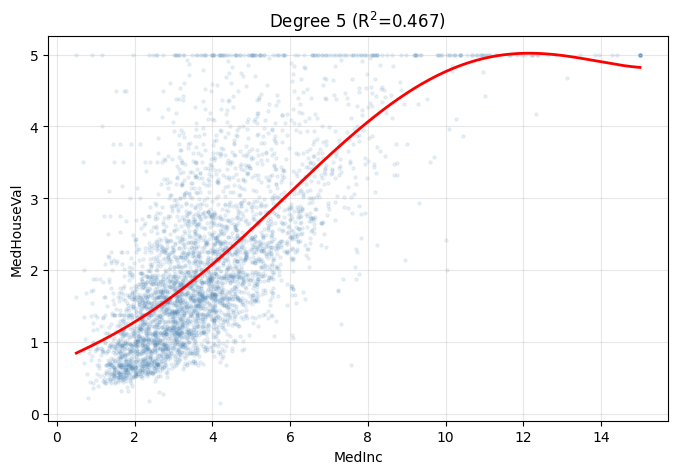


Observation for Degree 5 (MedInc only):
The R² value for degree 5 (0.4700) is slightly higher than degree 3 (0.4671), this means it explains a little more of the changes in house prices. 
However, the curve for degree 5 looks more wavy, it starts to bend too much at the edges of the graph. 
This may be overfitting, which means the model is learning small random details in the data instead of the real pattern.

Original features: 8
After degree-3 expansion: 164

Degree 3 creates more features, which makes the model more complex. 
A more complex model can capture more detailed patterns but it can also fit the training data too closely. 
If that happens, it may not perform as well on new data.


In [188]:
#Try degree 5 on the single-feature model. Does R2 keep improving, or does it start to behave strangely at the edges? This is overfitting!

# Re-prepare data for single feature (MedInc)
X_simple = df [['MedInc']].values
X_train_s , X_test_s , y_train , y_test = train_test_split(
    X_simple , y , test_size =0.2 , random_state =42)

# Train with degree 5
pipe_poly_deg5 = Pipeline ([
    ('poly', PolynomialFeatures ( degree =5 , include_bias = False ) ) ,
    ('lr', LinearRegression () )
])
pipe_poly_deg5 . fit ( X_train_s , y_train )
y_pred_deg5 = pipe_poly_deg5 . predict ( X_test_s )

r2_deg5 = r2_score ( y_test , y_pred_deg5 )
rmse_deg5 = np . sqrt ( mean_squared_error ( y_test , y_pred_deg5 ) )

print (f"Degree 5 (MedInc only): R^2={r2_deg5:.4f}, RMSE={rmse_deg5:.4f}\n")

# Plot for degree 5
plt . figure ( figsize =(8 , 5) )
plt . scatter ( X_test_s , y_test , alpha =0.1 , s =5 , color ='steelblue' )
x_plot_deg5 = np . linspace ( X_test_s .min () , X_test_s .max () , 300) . reshape ( -1 , 1)
y_plot_deg5 = pipe_poly_deg5 . predict ( x_plot_deg5 )
plt . plot ( x_plot_deg5 , y_plot_deg5 , color ='red', linewidth =2)
plt . title ( f'Degree 5 (R$ ^2$={ r2_deg5 :.3f}) ')
plt . xlabel ('MedInc')
plt . ylabel ('MedHouseVal')
plt . grid (True, alpha=0.3)
plt . show ()

print("\nObservation for Degree 5 (MedInc only):")
print("The R² value for degree 5 (0.4700) is slightly higher than degree 3 (0.4671), this means it explains a little more of the changes in house prices. \nHowever, the curve for degree 5 looks more wavy, it starts to bend too much at the edges of the graph. \nThis may be overfitting, which means the model is learning small random details in the data instead of the real pattern.")

#How many features does degree 3 create from 8 original features? Use PolynomialFeatures(degree=3).fit transform(X train).shape to check.

poly_deg3_all = PolynomialFeatures(degree=3, include_bias=False)
X_train_all_poly_deg3 = poly_deg3_all.fit_transform(X_train)

original_features_count = X_train.shape[1]
expanded_features_count = X_train_all_poly_deg3.shape[1]

print(f"\nOriginal features: {original_features_count}")
print(f"After degree-3 expansion: {expanded_features_count}")
print("\nDegree 3 creates more features, which makes the model more complex. \nA more complex model can capture more detailed patterns but it can also fit the training data too closely. \nIf that happens, it may not perform as well on new data.")

#Part 7: Regularized Regression – Ridge, Lasso, and ElasticNet

##7.1 Train All Three Variants


In [189]:
from sklearn . linear_model import Ridge , Lasso , ElasticNet

# Split data
X_train , X_test , y_train , y_test = train_test_split (
X_all , y , test_size =0.2 , random_state =42)

# Define models with pipelines
models = {
'LinearRegression': Pipeline ([
('scaler', StandardScaler () ) ,
('model', LinearRegression () )
]) ,
'Ridge ( alpha =1.0)': Pipeline ([
('scaler', StandardScaler () ) ,
('model', Ridge ( alpha =1.0 , random_state =42) )
]) ,
'Lasso ( alpha =0.01)': Pipeline ([
('scaler', StandardScaler () ) ,
('model', Lasso ( alpha =0.01 , random_state =42) )
]) ,
'ElasticNet ( alpha =0.01)': Pipeline ([
('scaler', StandardScaler () ) ,
('model', ElasticNet ( alpha =0.01 , l1_ratio =0.5 ,
random_state =42) )
]) ,
}

# Train and evaluate each model
print ( f'{" Model ": <28} {" RMSE ": >8} {" MAE ": >8} {"R ^2": >8} ')
print ('-' * 56)

results_dict = {}
for name , pipe in models . items () :
    pipe . fit ( X_train , y_train )
    y_pred = pipe . predict ( X_test )

    rmse_val = np . sqrt ( mean_squared_error ( y_test , y_pred ) )
    mae_val = mean_absolute_error ( y_test , y_pred )
    r2_val = r2_score ( y_test , y_pred )

    results_dict [ name ] = {
'RMSE ': rmse_val , 'MAE ': mae_val , 'R2 ': r2_val }
    print ( f'{ name : <28} { rmse_val : >8.4f} { mae_val : >8.4f} '
f'{ r2_val : >8.4f}')

 Model                          RMSE      MAE      R ^2 
--------------------------------------------------------
LinearRegression               0.7456   0.5332   0.5758
Ridge ( alpha =1.0)            0.7456   0.5332   0.5758
Lasso ( alpha =0.01)           0.7404   0.5353   0.5816
ElasticNet ( alpha =0.01)      0.7416   0.5341   0.5803


##7.2 Compare Coefficients

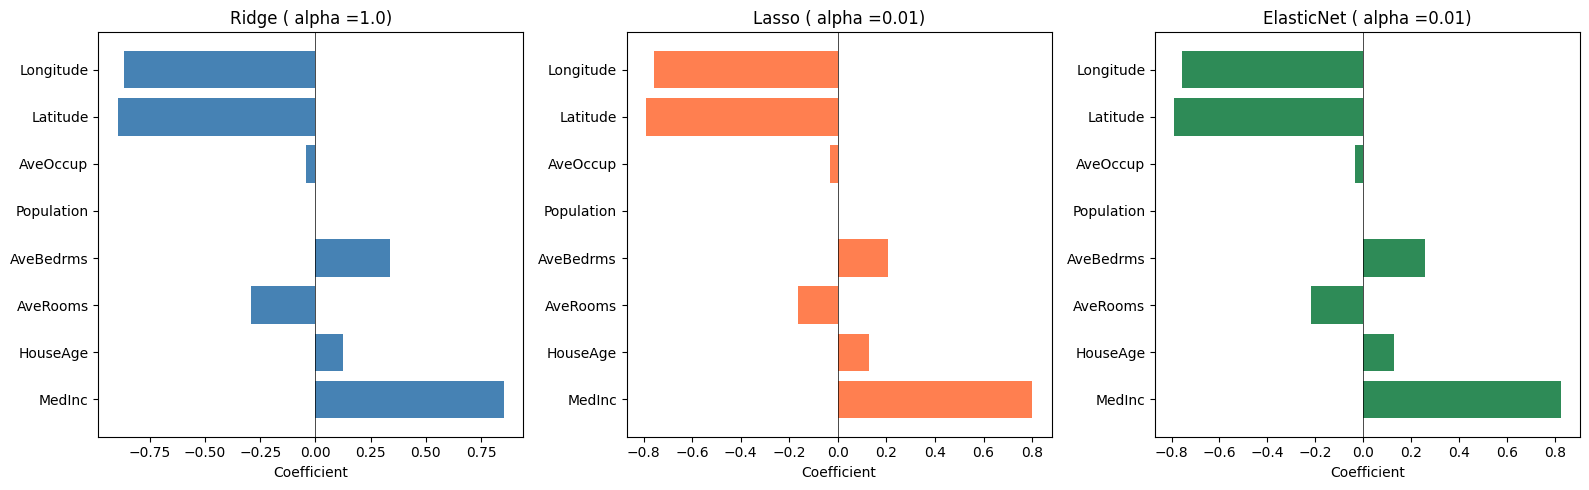


Lasso coefficients :
 MedInc      :   0.8010
 HouseAge    :   0.1271
 AveRooms    :  -0.1628
 AveBedrms   :   0.2062
 Population  :  -0.0000 <-- REMOVED 
 AveOccup    :  -0.0306
 Latitude    :  -0.7901
 Longitude   :  -0.7557


In [190]:
fig , axes = plt . subplots (1 , 3 , figsize =(16 , 5) )
model_names = ['Ridge ( alpha =1.0)',
'Lasso ( alpha =0.01)',
'ElasticNet ( alpha =0.01)']
colors_list = ['steelblue', 'coral', 'seagreen']

for ax , name , clr in zip( axes , model_names , colors_list ) :
    coefs = models [ name ]. named_steps ['model']. coef_
    ax . barh ( housing . feature_names , coefs , color = clr )
    ax . set_title ( name )
    ax . axvline ( x =0 , color ='black', linewidth =0.5)
    ax . set_xlabel ('Coefficient')

plt . tight_layout ()
plt . show ()

# Check which features Lasso set to zero
lasso_coefs = models ['Lasso ( alpha =0.01)']. named_steps ['model']. coef_
print ('\nLasso coefficients :')
for feat , coef in zip( housing . feature_names , lasso_coefs ) :
    status = '' if abs ( coef ) > 0.001 else ' <-- REMOVED '
    print ( f' { feat :12s}: { coef : >8.4f}{ status }')

#Task 6: Explore Regularization

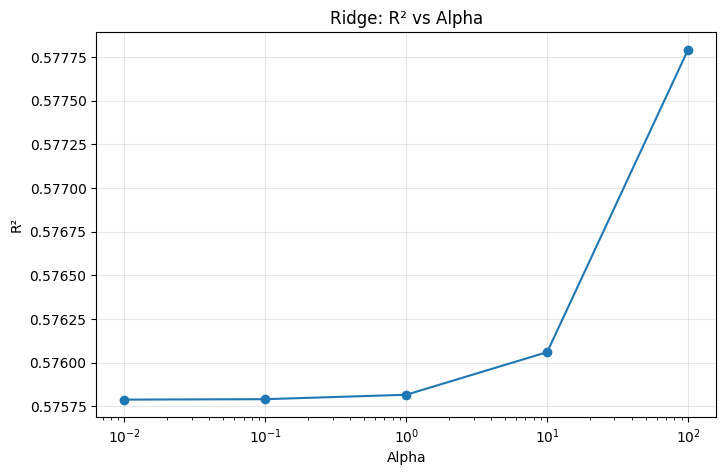


Lasso (alpha=0.1) coefficients:
MedInc      :   0.7106
HouseAge    :   0.1065
AveRooms    :  -0.0000 <-- REMOVED
AveBedrms   :   0.0000 <-- REMOVED
Population  :  -0.0000 <-- REMOVED
AveOccup    :  -0.0000 <-- REMOVED
Latitude    :  -0.0115
Longitude   :  -0.0000 <-- REMOVED

Total features removed: 5

ElasticNet (l1_ratio=0.0): R² = 0.5784
ElasticNet (l1_ratio=0.5): R² = 0.5803
ElasticNet (l1_ratio=1.0): R² = 0.5816


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.465e+03, tolerance: 2.207e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


In [191]:
#Try different α values for Ridge: 0.01, 0.1, 1.0, 10.0, 100.0. Plot R2 vs α. What happens with very large α?
#to-do
# Different alpha values for Ridge
alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0]
r2_scores = []

for alpha in alpha_values:
    ridge_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha, random_state=42))
    ])

    ridge_pipe.fit(X_train, y_train)
    r2 = ridge_pipe.score(X_test, y_test)
    r2_scores.append(r2)

# Plot R² vs alpha
plt.figure(figsize=(8,5))
plt.plot(alpha_values, r2_scores, marker='o')
plt.xscale('log')  # log scale makes it clearer
plt.xlabel('Alpha')
plt.ylabel('R²')
plt.title('Ridge: R² vs Alpha')
plt.grid(True, alpha=0.3)
plt.show()

#For Lasso, try alpha=0.1. How many features are removed (coefficient = 0)? Which ones?
#to-do
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.1, random_state=42))
])

lasso_pipe.fit(X_train, y_train)

lasso_coefs = lasso_pipe.named_steps['model'].coef_

print("\nLasso (alpha=0.1) coefficients:")
removed_count = 0

for feat, coef in zip(housing.feature_names, lasso_coefs):
    if abs(coef) < 0.0001:
        print(f"{feat:12s}: {coef:8.4f} <-- REMOVED")
        removed_count += 1
    else:
        print(f"{feat:12s}: {coef:8.4f}")

print(f"\nTotal features removed: {removed_count}\n")

#In the ElasticNet, change l1 ratio from 0.0 to 1.0. At l1 ratio=0.0, what model does it become? At l1 ratio=1.0?
#to-do
l1_values = [0.0, 0.5, 1.0]

for l1 in l1_values:
    elastic_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=l1, random_state=42))
    ])

    elastic_pipe.fit(X_train, y_train)
    r2 = elastic_pipe.score(X_test, y_test)

    print(f"ElasticNet (l1_ratio={l1}): R² = {r2:.4f}")

**1. Try different α values for Ridge: 0.01, 0.1, 1.0, 10.0, 100.0. Plot R2 vs α. What happens with very large α?**

> As alpha increases from 0.01 to 100, the R² value slightly improves. With very large alpha, Ridge regression makes the model coefficients very small, potentially causing the model to underfit and predict closer to the average house value.

**2. For Lasso, try alpha=0.1. How many features are removed (coefficient = 0)? Which ones?**

> With alpha=0.1, Lasso removed 5 features by setting their coefficients to zero. These features are 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', and 'Longitude'.

**3. In the ElasticNet, change l1 ratio from 0.0 to 1.0. At l1 ratio=0.0, what model does it become? At l1 ratio=1.0?**

> When l1_ratio = 0.0, ElasticNet becomes a Ridge Regression model. When l1_ratio = 1.0, ElasticNet becomes a Lasso Regression model.

#Part 8: The Alpha Tuning Experiment

##8.1 Ridge Alpha Search

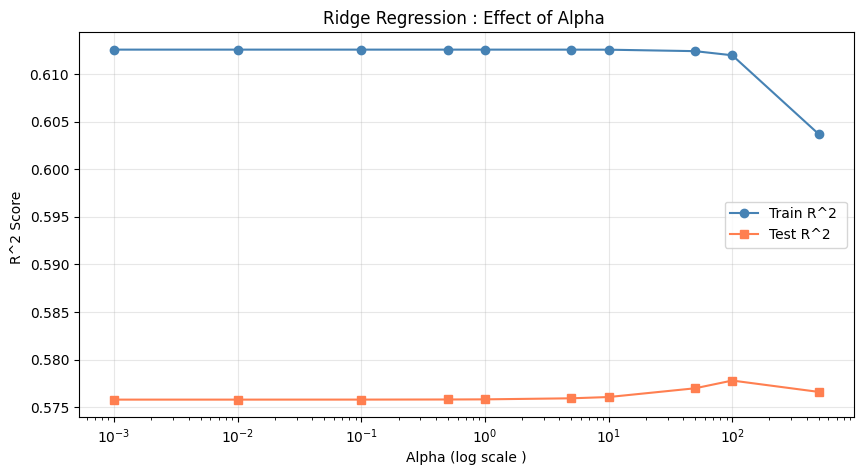


Best alpha : 100.0 
Best test R^2: 0.5778


In [192]:
alphas = [0.001 , 0.01 , 0.1 , 0.5 , 1.0 , 5.0 , 10.0 ,
50.0 , 100.0 , 500.0]

train_scores = []
test_scores = []

for alpha in alphas :
    pipe = Pipeline ([
    ('scaler', StandardScaler () ) ,
    ('ridge', Ridge ( alpha = alpha ) )
    ])
    pipe . fit ( X_train , y_train )
    train_scores . append ( r2_score ( y_train ,
    pipe . predict ( X_train ) ) )
    test_scores . append ( r2_score ( y_test ,
    pipe . predict ( X_test ) ) )

# Plot
plt . figure ( figsize =(10 , 5) )
plt . semilogx ( alphas , train_scores , 'o-',
label ='Train R^2 ', color ='steelblue')
plt . semilogx ( alphas , test_scores , 's-',
label ='Test R^2 ', color ='coral')
plt . xlabel ('Alpha (log scale )')
plt . ylabel ('R^2 Score ')
plt . title ('Ridge Regression : Effect of Alpha ')
plt . legend ()
plt . grid (True , alpha =0.3)
plt . show ()

# Best alpha
best_idx = np . argmax ( test_scores )
print ( f'\nBest alpha : { alphas [ best_idx ]} ')
print ( f'Best test R^2: { test_scores [ best_idx ]:.4f}')

#Task 7: Tune Lasso Alpha

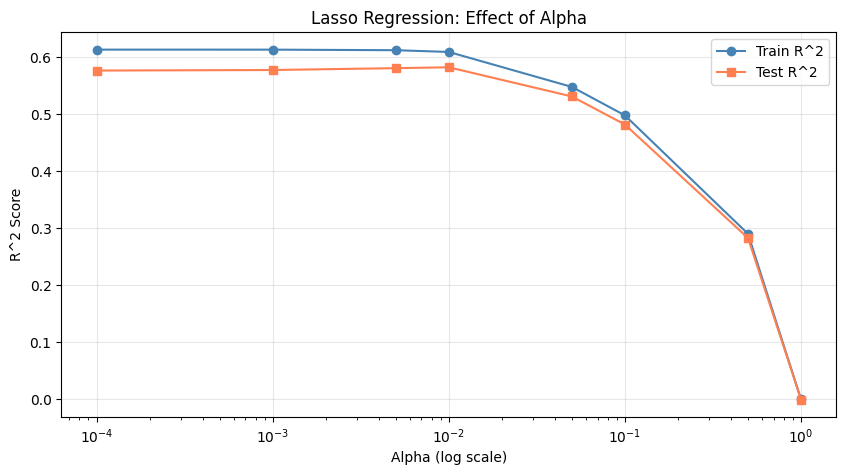


Alpha | Features Kept
------------------------------
0.0001   | 8
0.001    | 8
0.005    | 7
0.01     | 7
0.05     | 4
0.1      | 3
0.5      | 1
1.0      | 0

Lasso starts removing features as alpha increases. 
It starts removing features more noticeably at alpha = 0.05, where the number drops from 7 to 4. For larger values like 0.5 and 1.0, it removes almost all features.

Best alpha: 0.01
Best test R^2: 0.5816

This means alpha = 0.01 gives the best performance for Lasso.


In [193]:
#Repeat the alpha search experiment for Lasso using alphas: [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0].
from sklearn.linear_model import Lasso

alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

train_scores = []
test_scores = []
features_kept = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, random_state=42, max_iter=10000))
    ])

    pipe.fit(X_train, y_train)

    # R² scores
    train_scores.append(r2_score(y_train, pipe.predict(X_train)))
    test_scores.append(r2_score(y_test, pipe.predict(X_test)))

    # Count non-zero coefficients
    coefs = pipe.named_steps['lasso'].coef_
    non_zero = np.sum(np.abs(coefs) > 0.0001)
    features_kept.append(non_zero)


#Plot train and test R2 vs alpha, just like the Ridge plot above.
# Plot
plt.figure(figsize=(10,5))
plt.semilogx(alphas, train_scores, 'o-', label='Train R^2', color='steelblue')
plt.semilogx(alphas, test_scores, 's-', label='Test R^2', color='coral')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 Score')
plt.title('Lasso Regression: Effect of Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#For each alpha, count how many features Lasso keeps (coefficient ̸= 0). At what alpha does Lasso start removing features aggressively?
print("\nAlpha | Features Kept")
print("-" * 30)

for alpha, kept in zip(alphas, features_kept):
    print(f"{alpha:<8} | {kept}")

print("\nLasso starts removing features as alpha increases. \nIt starts removing features more noticeably at alpha = 0.05, where the number drops from 7 to 4. For larger values like 0.5 and 1.0, it removes almost all features.")

#Which alpha gives the best test R2 for Lasso?
# Best alpha
best_idx = np.argmax(test_scores)
print(f'\nBest alpha: {alphas[best_idx]}')
print(f'Best test R^2: {test_scores[best_idx]:.4f}')

print("\nThis means alpha = 0.01 gives the best performance for Lasso.")

#Part 9: Final Model Comparison


##9.1  Comprehensive Comparison

In [194]:
# Rebuild all models on the same split
X_train , X_test , y_train , y_test = train_test_split (
X_all , y , test_size =0.2 , random_state =42)

all_models = {
'Simple LR ( MedInc )': Pipeline ([
('lr' , LinearRegression () )
]) ,
'Multiple LR ( all)': Pipeline ([
('scaler' , StandardScaler () ) ,
('lr' , LinearRegression () )
]) ,
'Polynomial ( deg =2)': Pipeline ([
('scaler' , StandardScaler () ) ,
('poly' , PolynomialFeatures ( degree =2 ,
include_bias = False ) ) ,
('lr' , LinearRegression () )
]) ,
'Ridge': Pipeline ([
('scaler' , StandardScaler () ) ,
('model' , Ridge ( alpha =1.0) )
]) ,
'Lasso': Pipeline ([
('scaler' , StandardScaler () ) ,
('model' , Lasso ( alpha =0.01) )
]) ,
'ElasticNet': Pipeline ([
('scaler' , StandardScaler () ) ,
('model' , ElasticNet ( alpha =0.01 , l1_ratio =0.5) )
]) ,
}

# Evaluate
print ( f'{" Model ": <25} {" RMSE ": >8} {" MAE ": >8} '
f'{"R ^2": >8} {"# Features ": >10} ')
print ('=' * 67)

comparison_data = []
for name , pipe in all_models . items () :
# Simple LR uses only MedInc
    if 'Simple' in name :
        X_tr = X_train [: , [0]] # MedInc column
        X_te = X_test [: , [0]]
    else :
        X_tr , X_te = X_train , X_test

    pipe . fit ( X_tr , y_train )
    y_pred = pipe . predict ( X_te )

    rmse_v = np . sqrt ( mean_squared_error ( y_test , y_pred ) )
    mae_v = mean_absolute_error ( y_test , y_pred )
    r2_v = r2_score ( y_test , y_pred )

# Count effective features
    if 'poly' in pipe . named_steps :
        n_feat = pipe . named_steps ['poly']. n_output_features_
    elif 'Simple' in name :
        n_feat = 1
    else :
        n_feat = X_train . shape [1]

    comparison_data . append ({
'Model ': name , 'RMSE ': rmse_v ,
'MAE ': mae_v , 'R2 ': r2_v , 'Features ': n_feat })
    print ( f'{ name : <25} { rmse_v : >8.4f} { mae_v : >8.4f} '
f'{ r2_v : >8.4f} { n_feat : >10} ')

 Model                       RMSE      MAE      R ^2 # Features  
Simple LR ( MedInc )        0.8421   0.6299   0.4589          1 
Multiple LR ( all)          0.7456   0.5332   0.5758          8 
Polynomial ( deg =2)        0.6814   0.4670   0.6457         44 
Ridge                       0.7456   0.5332   0.5758          8 
Lasso                       0.7404   0.5353   0.5816          8 
ElasticNet                  0.7416   0.5341   0.5803          8 


##9.2 Visual Comparison

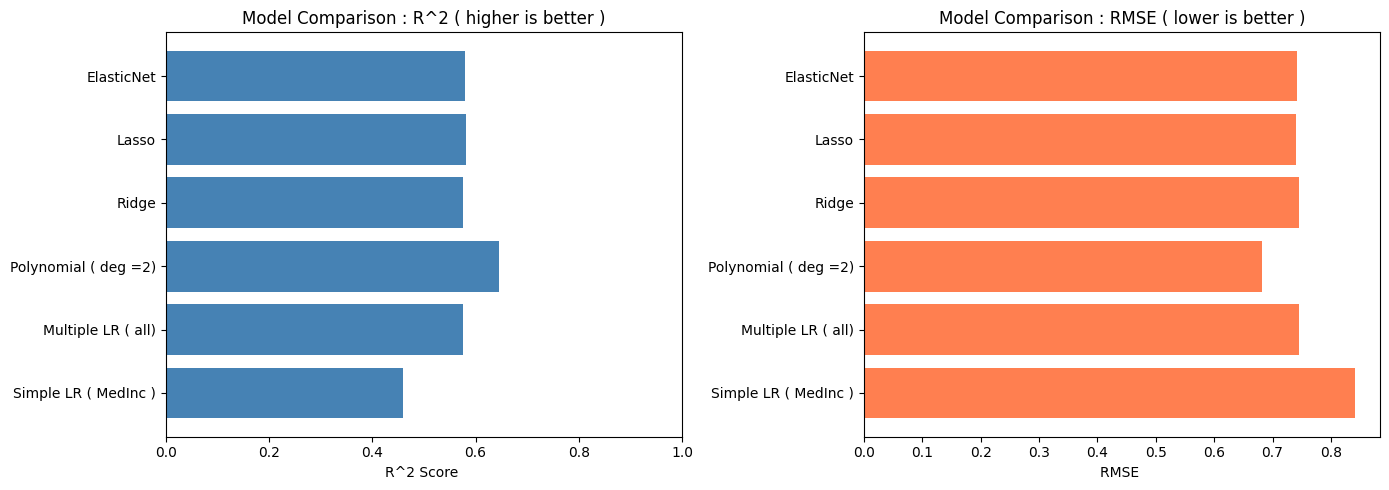

In [195]:
comp_df = pd . DataFrame ( comparison_data )

fig , axes = plt . subplots (1 , 2 , figsize =(14 , 5) )

# R^2 comparison
axes [0]. barh ( comp_df ['Model '] , comp_df ['R2 '] , color ='steelblue')
axes [0]. set_xlabel ('R^2 Score ')
axes [0]. set_title ('Model Comparison : R^2 ( higher is better )')
axes [0]. set_xlim (0 , 1)

# RMSE comparison
axes [1]. barh ( comp_df ['Model '] , comp_df ['RMSE '] , color ='coral')
axes [1]. set_xlabel ('RMSE ')
axes [1]. set_title ('Model Comparison : RMSE ( lower is better )')

plt . tight_layout ()
plt . show ()

#Task 8: Draw Conclusions


**1. Which model achieved the best R2 on the test set? Which had the lowest RMSE?**

> The Polynomial (degree 2) model achieved the best R2 (0.6457) and the lowest RMSE (0.6814) on the test set.

**2. The Polynomial (degree 2) model uses 44 features. Is the improvement in R2 worth the added complexity? Justify your answer.**

> The R² improved from 0.5758 to 0.6457 which is about a 7% increase in explained variance. This is a noticeable improvement. However, the polynomial model uses 44 features, which makes it more complex. If prediction accuracy is very important, the improvement may be worth it but the model becomes harder to understand and manage.

**3. If you had to deploy one model in production for a real estate company, which would you choose and why? Consider accuracy, interpretability, and simplicity.**

> I would choose the Multiple Linear Regression model. It has good accuracy and is much simpler. It is easier to explain how each feature affects house price. For a real estate company, interpretability is very important. Even though the polynomial model is more accurate, it is harder to explain.

**4. Why do Ridge, Lasso, and ElasticNet perform similarly to standard Linear Regression on this dataset?**

> They perform similarly because the dataset does not have serious problems like too many useless features or similar features. The normal Linear Regression model already fits the data well. So adding regularization does not change the results much. Also, the alpha values may not have been large enough to create big differences.

#Part 10: Apply to a New Dataset – Saudi Housing

##10.1  Create the Saudi Housing Dataset

In [196]:
import pandas as pd
import numpy as np

np . random . seed (42)
n = 500

cities = np . random . choice (
['Jeddah ', 'Riyadh ', 'Dammam ', 'Makkah ', 'Madinah '] ,
n , p =[0.30 , 0.30 , 0.15 , 0.15 , 0.10])

# Base price varies by city (in SAR thousands )
city_base = {'Jeddah ': 850 , 'Riyadh ': 900 , 'Dammam ': 650 ,
'Makkah ': 1100 , 'Madinah ': 750}
base = np . array ([ city_base [ c ] for c in cities ] , dtype = float )

area = np . round ( np . random . uniform (80 , 400 , n ) , 1)
bedrooms = np . random . randint (1 , 7 , n )
bathrooms = np . random . randint (1 , 5 , n )
age = np . random . randint (0 , 40 , n )
floor = np . random . randint (1 , 15 , n )
has_parking = np . random . choice ([0 , 1] , n , p =[0.3 , 0.7])

# Generate price with realistic relationships
price = ( base
+ 3.5 * area
+ 80 * bedrooms
+ 50 * bathrooms
- 12 * age
+ 15 * floor
+ 100 * has_parking
+ np . random . normal (0 , 150 , n ) ) # noise
price = np . round ( np . maximum ( price , 200) , 1)

df_saudi = pd . DataFrame ({
'city ': cities ,
'area_sqm ': area ,
'bedrooms ': bedrooms ,
'bathrooms ': bathrooms ,
'age_years ': age ,
'floor ': floor ,
'has_parking ': has_parking ,
'price_kSAR ': price # price in thousands of SAR
})

df_saudi . to_csv ('saudi_housing.csv', index = False )
print ( f'Dataset shape : { df_saudi . shape }')
print ( df_saudi . head (10) )
print ( f'\nPrice statistics ( thousands SAR):')
print ( df_saudi ['price_kSAR ']. describe () . round (1) )

Dataset shape : (500, 8)
      city   area_sqm   bedrooms   bathrooms   age_years   floor   \
0   Riyadh       303.4          4           4          24      11   
1  Madinah       251.6          6           4           1       1   
2   Dammam       179.0          3           1          34      14   
3   Riyadh       340.4          5           3           6      14   
4   Jeddah       299.1          1           3          20       6   
5   Jeddah       132.0          5           4          17      13   
6   Jeddah       371.5          6           2           2       6   
7   Makkah       343.2          6           3          38       1   
8   Dammam       383.9          1           3          10      11   
9   Dammam       312.2          2           1          38      13   

   has_parking   price_kSAR   
0             0       2527.3  
1             1       2491.2  
2             0       1345.8  
3             1       2941.9  
4             0       2022.0  
5             1       2264.8 

#Task 9: Full Saudi Housing Analysis (Challenge)

=== Dataset Shape ===
(500, 8)

=== First 5 Rows ===
      city   area_sqm   bedrooms   bathrooms   age_years   floor   \
0   Riyadh       303.4          4           4          24      11   
1  Madinah       251.6          6           4           1       1   
2   Dammam       179.0          3           1          34      14   
3   Riyadh       340.4          5           3           6      14   
4   Jeddah       299.1          1           3          20       6   

   has_parking   price_kSAR   
0             0       2527.3  
1             1       2491.2  
2             0       1345.8  
3             1       2941.9  
4             0       2022.0  

=== Basic Statistics ===
       area_sqm   bedrooms   bathrooms   age_years   floor   has_parking   \
count     500.00     500.00      500.00       500.0  500.00        500.00   
mean      234.22       3.50        2.45        19.6    7.52          0.71   
std        91.36       1.71        1.13        11.6    3.97          0.46   
min        8

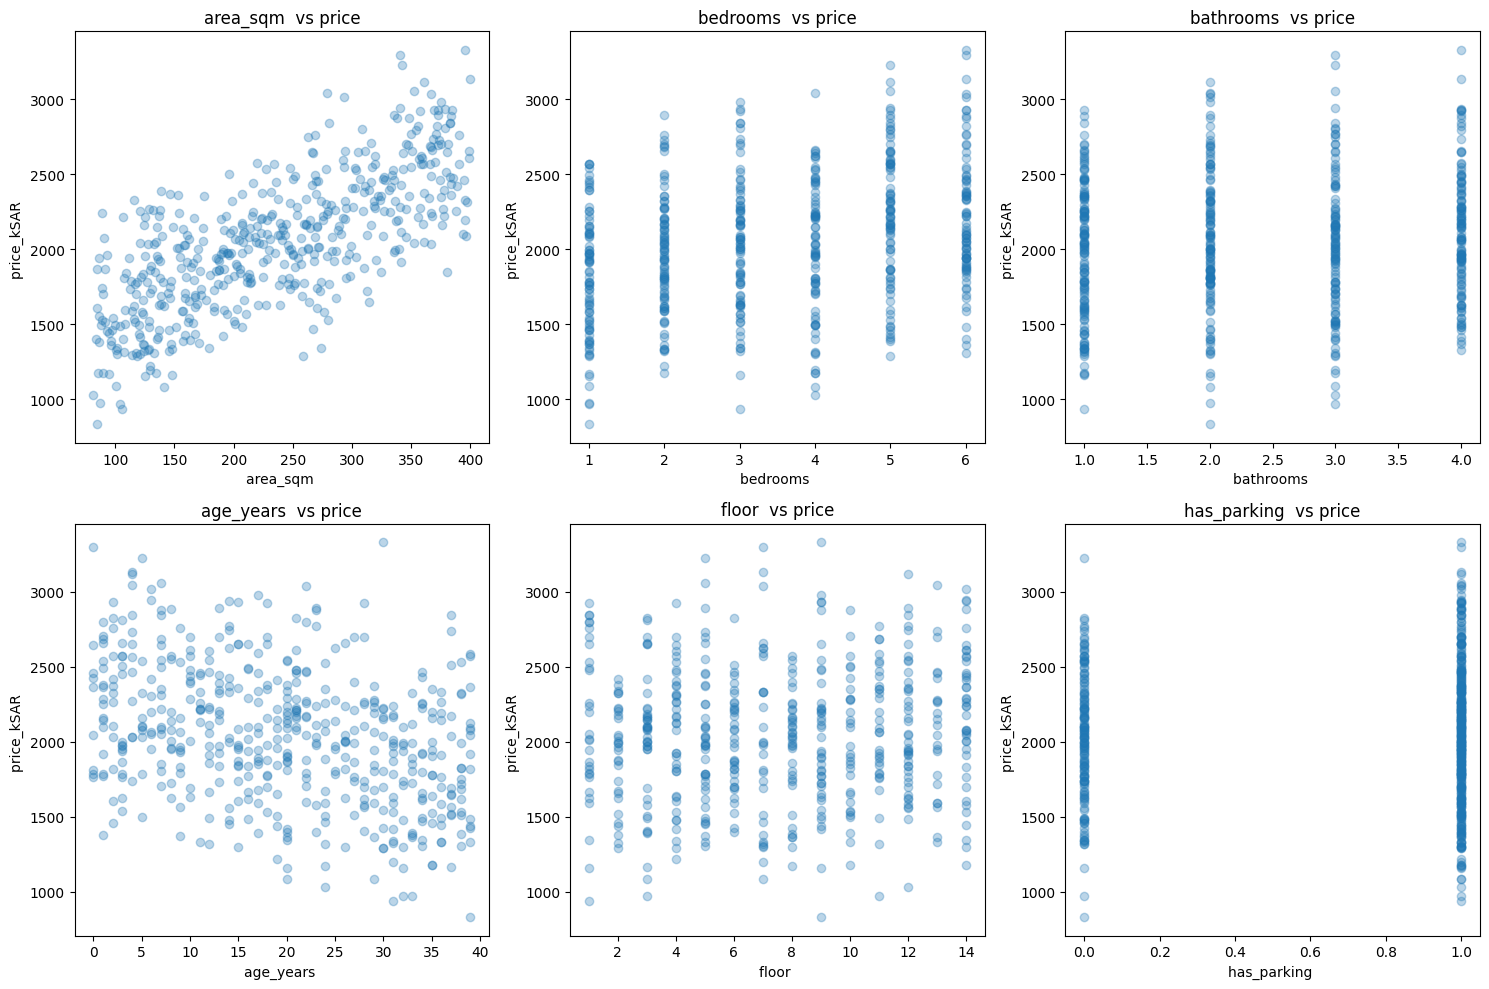


=== Simple Linear Regression (area_sqm only) ===
RMSE: 334.6661
MAE: 276.0584
R2: 0.4932



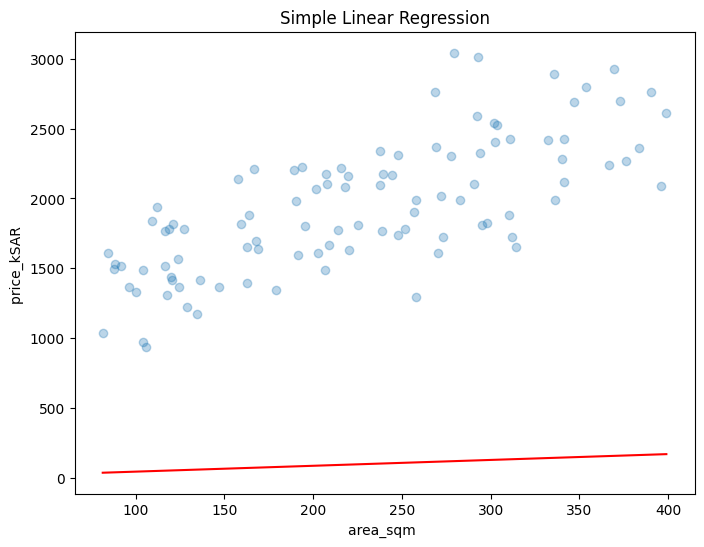


=== Multiple Linear Regression (All Features) ===
RMSE: 173.0295
MAE: 137.3012
R2: 0.8645
R2 Improvement: 0.3714

=== LinearRegression ===
RMSE: 173.0295
MAE: 137.3012
R2: 0.8645

=== Ridge ===
RMSE: 173.8703
MAE: 138.6488
R2: 0.8632

=== Lasso ===
RMSE: 173.0374
MAE: 137.3102
R2: 0.8645

=== ElasticNet ===
RMSE: 175.1153
MAE: 140.0952
R2: 0.8612

=== Lasso Feature Importance ===
          Feature  Coefficient
8   city _Makkah    514.104817
0       area_sqm    333.993777
9   city _Riyadh    277.578275
6   city _Jeddah    225.520209
1       bedrooms    142.299173
3      age_years   -128.051316
7  city _Madinah    127.007304
4          floor     74.014637
2      bathrooms     53.945312
5    has_parking     42.218987

Features removed by Lasso (coef = 0):
Empty DataFrame
Columns: [Feature, Coefficient]
Index: []

=== FINAL MODEL COMPARISON ===
                        RMSE         MAE        R2
LinearRegression  173.029522  137.301214  0.864517
Ridge             173.870282  138.648753  0.

In [197]:
#Apply everything you learned in this lab to the saudi housing.csv dataset:
#1. Explore: Use df.describe(), df.corr(), and scatter plots to understand the data. Which feature correlates most with price?
#2. Preprocess: Encode the city column using One-Hot encoding (from Lab 3). Scale the numeric features.
#3. Simple model: Train a Linear Regression using only area sqm. Plot the regression line and report R2.
#4. Multiple model: Train with all features. How much does R2 improve?
#5. Regularized models: Train Ridge, Lasso, and ElasticNet. Compare their performance.
#6. Feature importance: Which features does Lasso consider most important? Does this match your intuition about Saudi housing prices?
#7. Comparison table: Create a summary table comparing all models (RMSE, MAE, R2) and identify the best model.
#This task combines skills from Labs 3 and 4. Use pipelines throughout!

# ============================================================
# TASK 9: FULL SAUDI HOUSING ANALYSIS (CHALLENGE)
# ============================================================

# ============================================================
# SECTION 1: LOAD & EXPLORE THE DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("saudi_housing.csv")

print("=== Dataset Shape ===")
print(df.shape)

print("\n=== First 5 Rows ===")
print(df.head())

print("\n=== Basic Statistics ===")
print(df.describe().round(2))

print("\n=== Correlation Matrix ===")
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix.round(3))

print("\n=== Correlation with Price ===")
target_corr = corr_matrix['price_kSAR '].sort_values(ascending=False)
print(target_corr)

print(f'\nFeature MOST correlated with price:{target_corr.index[1]}\n') # first is price itself

# Scatter plots
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('price_kSAR ')

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols[:6]):
    plt.subplot(2,3,i+1)
    plt.scatter(df[col], df['price_kSAR '], alpha=0.3)
    plt.xlabel(col)
    plt.ylabel("price_kSAR ")
    plt.title(f"{col} vs price")
plt.tight_layout()
plt.show()


# ============================================================
# SECTION 2: PREPROCESSING (ONE-HOT + SCALING)
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Separate target
X = df.drop(columns=['price_kSAR '])
y = df['price_kSAR ']

# Identify columns
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = ['city ']

# Preprocessing pipeline
# Instead of get_dummies inside ColumnTransformer,
# better use OneHotEncoder:

from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ============================================================
# SECTION 3: SIMPLE LINEAR REGRESSION (AREA ONLY)
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Use only area feature
X_area = df[['area_sqm ']].values

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_area, y, test_size=0.2, random_state=42
)

# Create a mini-pipeline for the simple model
pipe_simple = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe_simple.fit(X_train_s, y_train_s)
y_pred_simple = pipe_simple.predict(X_test_s)

rmse_simple = np.sqrt(mean_squared_error(y_test_s, y_pred_simple))
mae_simple = mean_absolute_error(y_test_s, y_pred_simple)
r2_simple = r2_score(y_test_s, y_pred_simple)

print("\n=== Simple Linear Regression (area_sqm only) ===")
print(f"RMSE: {rmse_simple:.4f}")
print(f"MAE: {mae_simple:.4f}")
print(f"R2: {r2_simple:.4f}\n")

# Plot regression line
plt.figure(figsize=(8,6))
plt.scatter(X_test_s, y_test_s, alpha=0.3)
x_line = np.linspace(X_test_s.min(), X_test_s.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1,1))
plt.plot(x_line, y_line, color='red')
plt.xlabel("area_sqm ")
plt.ylabel("price_kSAR ")
plt.title("Simple Linear Regression")
plt.show()


# ============================================================
# SECTION 4: MULTIPLE LINEAR REGRESSION (ALL FEATURES)
# ============================================================

pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipe_lr.fit(X_train, y_train)
y_pred_multi = pipe_lr.predict(X_test)

rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
mae_multi = mean_absolute_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("\n=== Multiple Linear Regression (All Features) ===")
print(f"RMSE: {rmse_multi:.4f}")
print(f"MAE: {mae_multi:.4f}")
print(f"R2: {r2_multi:.4f}")
print(f"R2 Improvement: {r2_multi - r2_simple:.4f}")


# ============================================================
# SECTION 5: REGULARIZED MODELS (RIDGE, LASSO, ELASTICNET)
# ============================================================

from sklearn.linear_model import Ridge, Lasso, ElasticNet

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5)
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = [rmse, mae, r2]

    print(f"\n=== {name} ===")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")


# ============================================================
# SECTION 6: LASSO FEATURE IMPORTANCE
# ============================================================

pipe_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.01))
])

pipe_lasso.fit(X_train, y_train)

# Get feature names after encoding
ohe = pipe_lasso.named_steps['preprocessor'].named_transformers_['cat']
encoded_features = ohe.get_feature_names_out(categorical_features)

all_features = numeric_features + list(encoded_features)

lasso_coefs = pipe_lasso.named_steps['model'].coef_

coef_df = pd.DataFrame({
    "Feature": all_features,
    "Coefficient": lasso_coefs
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\n=== Lasso Feature Importance ===")
print(coef_df)

print("\nFeatures removed by Lasso (coef = 0):")
print(coef_df[coef_df["Coefficient"] == 0])


# ============================================================
# SECTION 7: FINAL COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame(results,
                             index=["RMSE", "MAE", "R2"]).T

print("\n=== FINAL MODEL COMPARISON ===")
print(comparison_df)

best_model = comparison_df["R2"].idxmax()
print(f"\nBest Model Based on R2: {best_model}")

**1. Explore: Use df.describe(), df.corr(), and scatter plots to understand the data.*Which feature correlates most with price?***

> area_sqm (area in square meters) correlates most with the house price (price_kSAR ), with a correlation of 0.730.

**3. Simple model: Train a Linear Regression using only area sqm. Plot the regression line and *report R2*.**

> The simple linear regression model, using only area_sqm, achieved an R2 score of 0.4932.

**4. Multiple model: Train with all features. *How much does R2 improve?***

> The multiple linear regression model, using all features, improved the R2 by 0.3714 compared to the simple model, reaching an R2 of 0.8645.

**5. Regularized models: Train Ridge, Lasso, and ElasticNet. *Compare their performance.***

> The regularized models (Ridge, Lasso, ElasticNet) performed very similarly to the standard Linear Regression model on this dataset. They all achieved R2 scores around 0.86 (Linear Regression: 0.8645, Ridge: 0.8632, Lasso: 0.8645, ElasticNet: 0.8612). The RMSE and MAE values were also very close across these models.

**6. Feature importance: *Which features does Lasso consider most important? Does this match your intuition about Saudi housing prices?***

> Lasso considered city _Makkah , area_sqm , city _Riyadh , and city _Jeddah as the most important features (based on the absolute value of their coefficients). Yes, this matches intuition, as location (city) and size (area) are typically major drivers of housing prices.

**7. Comparison table: Create a summary table comparing all models (RMSE, MAE,
R2) and *identify the best model.***

> Based on R2, the Linear Regression model (using all features) was identified as the best model, closely followed by Lasso, both achieving an R2 of approximately 0.8645.

# Part 11: Summary and Key Takeaways

**1. Here's a quick summary of what we've done in this notebook:**

> In this notebook, We explored linear regression models, starting with a simple one using a single feature, then moving to multiple features, and finally experimenting with polynomial and regularized regression techniques. We applied these methods to the California Housing dataset and then to a newly generated Saudi Housing dataset, evaluating their performance and interpreting their results.

**2. A short report (5–7 sentences) comparing the regression models you trained. Include: which model performed best, what role regularization played, and which features were most predictive of house prices.**

> The Polynomial (degree 2) model achieved the best R2 (0.6457) and lowest RMSE (0.6814) on the California Housing dataset, demonstrating superior accuracy. However, its complexity (44 features) makes it less interpretable. Regularization techniques (Ridge, Lasso, ElasticNet) performed similarly to standard multiple linear regression for the California Housing dataset, suggesting that overfitting wasn't a major issue and the linear relationships were already well-captured. For the Saudi Housing dataset, area_sqm and city location (city _Makkah , city _Riyadh , city _Jeddah ) were the most predictive features. The multiple linear regression model offered a good balance of accuracy and interpretability across both datasets, making it a practical choice for deployment.